# Proof of Funds — Bitcoin Risk Quantification

When a cryptoasset service provider (CASP) receives an incoming Bitcoin transaction, AML rules require it to assess the risk that the funds are tied to illicit activity. This is the **Know-Your-Transaction (KYT)** problem.

This notebook walks through one approach:

1. **Load known-bad entities** from the open-source [GraphSense TagPacks](https://github.com/graphsense/graphsense-tagpacks) repository (~46k tagged BTC addresses across categories like `ransomware`, `darknet_market`, `exchange`, `mixer`, ...).
2. **Crawl a real Bitcoin subgraph** around a handful of tainted seed addresses via the [mempool.space](https://mempool.space/docs/api/rest) public REST API.
3. **Compute four complementary risk metrics** per address:
   - BFS hop **distance** to the nearest tainted source
   - **Direct exposure** — 1-hop tainted-value share
   - **Haircut taint** — multi-hop proportional propagation
   - **Aggregate score** — weighted 0–100 combination
4. **Analyze the distribution** of scores and trace one address's risk back to its source.

All cells run against real on-chain data; explorer responses are cached locally so re-runs are deterministic and offline.

## 1. Setup

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Make the package importable when running the notebook from the repo root.
sys.path.insert(0, str(Path.cwd().parent))

from pof.explorer import Explorer, crawl_neighborhood
from pof.graph import build_graph
from pof.metrics import (
    AggregateWeights,
    aggregate_score,
    direct_exposure,
    distance_to_tainted,
    haircut_taint,
)
from pof.metrics.distance import UNREACHABLE
from pof.tagpacks import discover_tagpack_files, load_tagpacks

# Silence the loader's per-pack warnings about missing labels — a few packs
# in the upstream repo have entries the schema considers incomplete.
logging.basicConfig(level=logging.WARNING)
logging.getLogger('pof.tagpacks').setLevel(logging.ERROR)

DATA = Path('../data')
TAGPACKS_DIR = DATA / 'tagpacks' / 'graphsense-tagpacks' / 'packs'

## 2. TagPack coverage

We load every YAML file in the cloned TagPacks repo and dedupe by address (keeping the most-severe tag if an address appears in multiple packs).

In [2]:
tagpack_files = discover_tagpack_files(TAGPACKS_DIR)
tags = load_tagpacks(tagpack_files)
print(f'loaded {len(tagpack_files)} pack files -> {len(tags):,} unique BTC addresses')
tags['severity'].value_counts().sort_index(ascending=False).rename('addresses').to_frame()

loaded 86 pack files -> 46,677 unique BTC addresses


,addresses
severity,
1.00,7512
0.85,178
0.80,278
0.60,16
0.50,109
0.30,63
0.00,38521


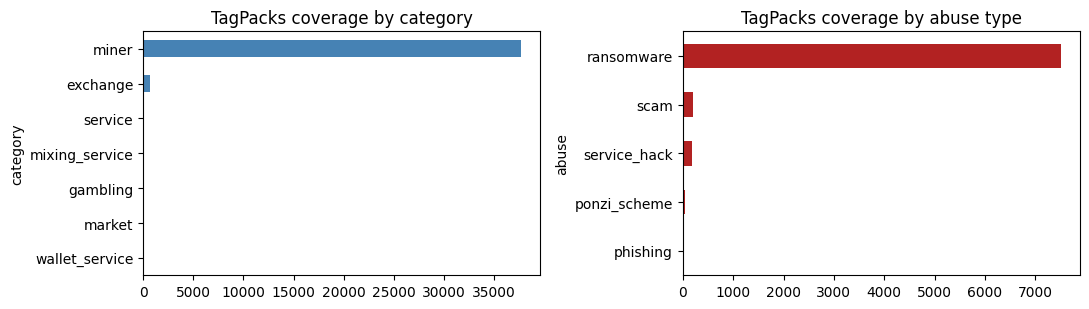

In [3]:
# Top categories and abuse types in the TagPacks corpus
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
tags['category'].value_counts().head(8).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('TagPacks coverage by category')
axes[0].invert_yaxis()
tags['abuse'].value_counts().plot.barh(ax=axes[1], color='firebrick')
axes[1].set_title('TagPacks coverage by abuse type')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Picking seed addresses

We need tagged addresses that are (a) high-severity and (b) actually have on-chain activity. The seeds in `data/seeds.txt` were picked by sampling each high-severity category and probing mempool.space for tx counts. They cover ransomware (Locky), investment scams, and the 2016 Bitfinex hack.

In [4]:
seeds = [line.strip() for line in (DATA / 'seeds.txt').read_text().splitlines()
         if line.strip() and not line.lstrip().startswith('#')]
tags.loc[seeds, ['label', 'category', 'abuse', 'confidence', 'severity']]

,label,category,abuse,confidence,severity
address,,,,,
1L7BisPWjZQ7hvXiirDmgydc6zKtFPXANw,Locky,NaN,ransomware,50,1.00
14CkwUznVHGM6nTXbrxbVtNdPXoojoVFeu,Locky,NaN,ransomware,50,1.00
12BCVTUtBhDJ6BEToBkUJjS6pcC8iC7kih,Locky,NaN,ransomware,50,1.00
12uDk9BctF2ywXz4qpGxJSprXG3uUD6Mda,giftbtc.org,NaN,scam,50,0.80
1JyRhM9ndcqacWkJRRnn2mbmQZ3XxcN7wy,chance.services,NaN,scam,50,0.80
16t35Fhe2HqKN5XT2ocEd9Fe3eKm5UhRcm,Bitfinex hack,NaN,service_hack,20,0.85


## 4. Crawl the neighborhood

Breadth-first crawl 1 hop out from each seed via mempool.space, capped at 25 transactions per address. Because each fetched transaction touches addresses on both sides, the resulting *address* graph naturally extends ~2 hops past the seeds.

Responses are cached in `data/cache/explorer.sqlite`, so this cell is essentially free on re-run.

In [5]:
explorer = Explorer(cache_path=DATA / 'cache' / 'explorer.sqlite')
txs = crawl_neighborhood(explorer, seeds, hops=1, max_tx_per_addr=25)
print(f'collected {len(txs)} unique transactions')

collected 2764 unique transactions


## 5. Build the proportional-attribution graph

For each transaction we add an edge from every input address to every output address, with weight `output_value × (input_value / total_input_value)`. This is the standard simplification used when full UTXO-level taint tracking is out of scope.

Tags from §2 are attached as node attributes.

In [6]:
g = build_graph(txs, tags=tags)
print(f'graph: {g.number_of_nodes():,} addresses, {g.number_of_edges():,} edges')
n_tainted = sum(1 for _, d in g.nodes(data=True) if d.get('severity', 0) > 0)
print(f'tainted nodes (severity > 0): {n_tainted}')

graph: 139,261 addresses, 762,166 edges
tainted nodes (severity > 0): 947


## 6. Run the four metrics

In [7]:
dist = distance_to_tainted(g)
direct = direct_exposure(g)
haircut = haircut_taint(g, damping=1.0)
score = aggregate_score(dist, direct, haircut, AggregateWeights())

df = pd.DataFrame({
    'distance': pd.Series(dist),
    'direct_exposure': pd.Series(direct),
    'haircut': pd.Series(haircut),
    'score': pd.Series(score),
})
df['label'] = df.index.map(lambda a: tags.at[a, 'label'] if a in tags.index else None)
df['category'] = df.index.map(lambda a: tags.at[a, 'category'] if a in tags.index else None)
df['abuse'] = df.index.map(lambda a: tags.at[a, 'abuse'] if a in tags.index else None)
df['severity'] = df.index.map(lambda a: float(tags.at[a, 'severity']) if a in tags.index else 0.0)
print(f'scored {len(df):,} addresses')
df.sort_values('score', ascending=False).head(10)

scored 139,261 addresses


,distance,direct_exposure,haircut,score,label,category,abuse,severity
12CjwjM6iQKYYdDACUxxujR7PXXHbqxBoH,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
1GNXwJWLcyYwWkW5UcvhZ7nLuqv5EP6yPS,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
1Krm6rAEvdZUucJ98p2EfTsVr4PnpKenAi,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
13ixvSRjcahBufANHrR9sFUjG9gegNdTHm,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
19XyYJCpsfgkC8yhYUKWTPbiht3GSsT2hM,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
1CbNZX5M6r5kPYNE5V16n45m5f2jJZbFro,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
18mswYMdzKsizmoPAe897iBr6kR3SzUZRY,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
1E82njZvbmacs9gv8Jc6FGpX75SKDwMsuC,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
12Rm4RNU4Vawo7ytvAx841a5CcmTdzhEB9,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0
1HMCDZAuBWzPhJ63uVFXtvmhFgxfyVPMPh,0,1.0,1.0,100.0,Locky,NaN,ransomware,1.0


## 7. Walkthrough: one address, four perspectives

Pick the highest-scoring untagged address. It's a downstream counterparty — exactly the sort of address a CASP would inspect on a deposit. We show how each of the four metrics rates it differently.

In [8]:
untagged = df[df['severity'] == 0.0]
if untagged.empty:
    case_addr = df.sort_values('score', ascending=False).index[0]
else:
    case_addr = untagged.sort_values('score', ascending=False).index[0]

row = df.loc[case_addr]
print(f'address: {case_addr}')
print(f'  BFS distance to tainted source: {int(row.distance) if row.distance >= 0 else "unreachable"}')
print(f'  direct exposure (1-hop):        {row.direct_exposure:.3f}')
print(f'  haircut taint (multi-hop):      {row.haircut:.3f}')
print(f'  aggregate score (0-100):        {row.score:.1f}')

address: 19ZNeFKh8Zcc3GzW2hR7tpQj2yDiyvhaim
  BFS distance to tainted source: 1
  direct exposure (1-hop):        1.000
  haircut taint (multi-hop):      1.000
  aggregate score (0-100):        88.7


## 8. Distribution analysis

How does the population of addresses look across each metric? For risk triage, we want a fat tail: most addresses should be benign, a few should be flagged.

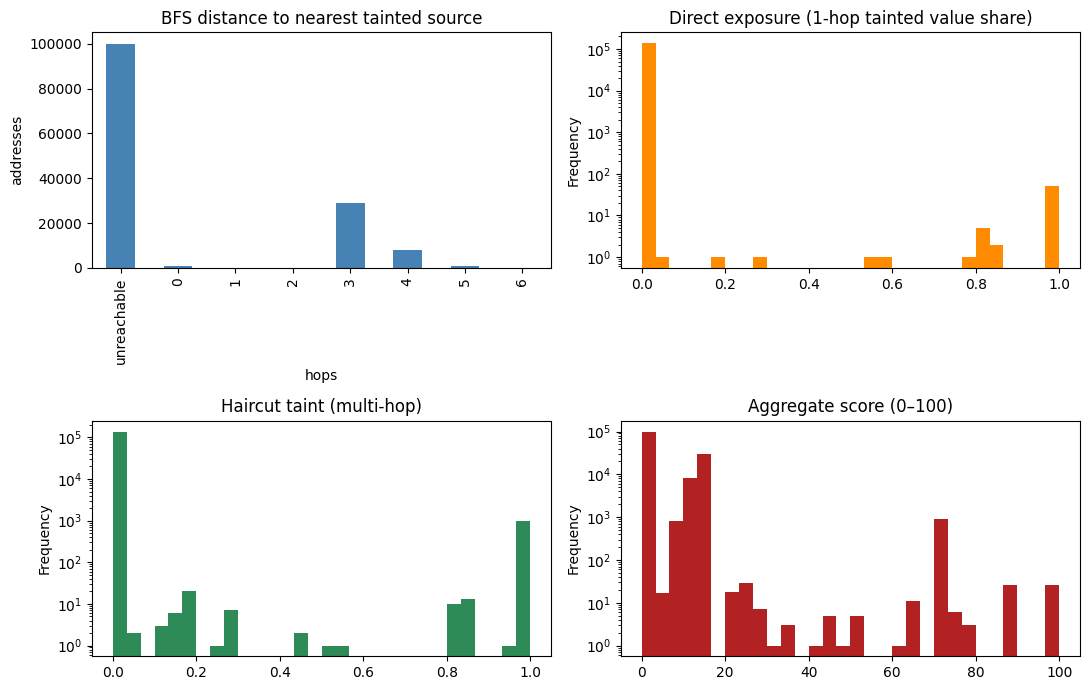

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Distance: bar chart (discrete)
dvc = df['distance'].replace(UNREACHABLE, -1).value_counts().sort_index()
dvc.index = ['unreachable' if i == -1 else str(int(i)) for i in dvc.index]
dvc.plot.bar(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('BFS distance to nearest tainted source')
axes[0, 0].set_xlabel('hops')
axes[0, 0].set_ylabel('addresses')

df['direct_exposure'].plot.hist(bins=30, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Direct exposure (1-hop tainted value share)')
axes[0, 1].set_yscale('log')

df['haircut'].plot.hist(bins=30, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Haircut taint (multi-hop)')
axes[1, 0].set_yscale('log')

df['score'].plot.hist(bins=30, ax=axes[1, 1], color='firebrick')
axes[1, 1].set_title('Aggregate score (0–100)')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

In [10]:
# How correlated are the metrics? A high correlation means they capture the
# same signal; a low correlation means they're complementary.
corr = df[['distance', 'direct_exposure', 'haircut', 'score']].copy()
# Map distance to a comparable scale: -1 (unreachable) -> +inf -> very high
corr['distance'] = corr['distance'].replace(-1, corr['distance'].max() + 5)
corr.corr().round(3)

,distance,direct_exposure,haircut,score
distance,1.000,-0.049,-0.211,-0.858
direct_exposure,-0.049,1.000,0.243,0.220
haircut,-0.211,0.243,1.000,0.676
score,-0.858,0.220,0.676,1.000


## 9. Case study: trace the path

For the worked address from §7, find the shortest path back to a tainted source. This is exactly the kind of explanation an analyst would attach to a flagged deposit.

In [11]:
tainted = [n for n, d in g.nodes(data=True) if d.get('severity', 0) > 0]
best_path = None
for src in tainted:
    try:
        p = nx.shortest_path(g, src, case_addr)
        if best_path is None or len(p) < len(best_path):
            best_path = p
    except nx.NetworkXNoPath:
        continue

if best_path is None:
    print('no path found — should not happen given case_addr was scored > 0')
else:
    print(f'shortest tainted-source path ({len(best_path)-1} hops):\n')
    for i, addr in enumerate(best_path):
        node = g.nodes[addr]
        tag_label = node.get('label')
        sev = node.get('severity', 0)
        suffix = f' [{tag_label} sev={sev:.2f}]' if tag_label else ''
        print(f'  {i}. {addr}{suffix}')
        if i + 1 < len(best_path):
            v = g[addr][best_path[i+1]].get('value_sat', 0)
            print(f'        --> {v:,} sat ({v/1e8:.6f} BTC)')

shortest tainted-source path (1 hops):

  0. 1L7BisPWjZQ7hvXiirDmgydc6zKtFPXANw [Locky sev=1.00]
        --> 11 sat (0.000000 BTC)
  1. 19ZNeFKh8Zcc3GzW2hR7tpQj2yDiyvhaim


## 10. Persist the scored table

The same DataFrame is what `python -m pof.precompute` writes to `data/results/scores.parquet`. Downstream consumers (a deposit-screening service, an analyst dashboard) can load it directly.

In [12]:
out = DATA / 'results' / 'notebook_scores.parquet'
out.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(out)
print(f'wrote {len(df):,} rows -> {out}')

wrote 139,261 rows -> ../data/results/notebook_scores.parquet


## 11. Limitations

- **Sampled subgraph.** mempool.space caps the per-address tx history to ~50 entries, and we cap further to 25 to keep the demo tractable. A production system would consume the full UTXO history (e.g. via the GraphSense Cassandra/Spark stack).
- **No address clustering.** We treat each address independently. The standard heuristic — collapsing co-spent inputs into a single entity — would substantially change the graph but is out of scope here.
- **Severity weights are illustrative.** Calibrate `pof/severity.py` against your own risk appetite and regulatory guidance.
- **Bitcoin only.** The same approach generalizes to UTXO chains; account-based chains (Ethereum) need a different graph model.
- **Static snapshot.** A deposit's risk depends on the chain *at the time of deposit*; this notebook re-fetches current state.